In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("plrx.txt", delimiter='\t', header=None).iloc[:, :13]

In [21]:
data.rename(columns={12: "Label"}, inplace=True)

In [22]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,Label
0,-0.17936,-0.207000,-0.209710,-0.097260,-0.119210,-0.173220,-0.280760,0.223170,0.418660,-0.032886,0.003383,-0.334250,1.0
1,-0.14659,-0.164940,0.249870,-0.073985,0.494940,-0.156330,-0.288910,0.500800,-0.045553,0.050759,-0.017511,0.066959,1.0
2,-0.13131,0.518160,0.432810,0.397890,0.043127,0.563200,-0.013246,-0.062833,-0.883390,-0.040303,0.088057,0.631200,2.0
3,0.64940,0.418780,0.148350,0.333490,-0.219740,0.398910,0.590650,0.077100,-1.107200,-0.367230,0.364680,0.571720,1.0
4,-0.40628,0.115030,0.073336,0.070066,-0.030920,0.152050,-0.191420,-0.580430,-0.102250,0.153750,-0.126950,0.184570,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,-0.55005,0.276290,-0.273240,0.113190,-0.776980,0.522660,-0.850620,0.440040,0.203910,-0.014462,0.002273,-0.100480,2.0
178,-0.78399,0.254600,-0.700990,-0.299170,-0.858330,0.210500,-0.530050,0.518550,-0.303190,0.020018,-0.020915,0.663940,1.0
179,0.29877,-0.179620,0.032859,-0.899010,0.540300,-0.361840,0.177900,0.713250,-0.098148,-0.411130,0.246830,-0.389160,2.0
180,-0.37812,-0.522870,0.215410,-0.243590,0.637840,-0.492210,-0.506930,-0.258110,-0.328990,-0.039117,0.007591,0.476030,1.0


Check for linear seperability

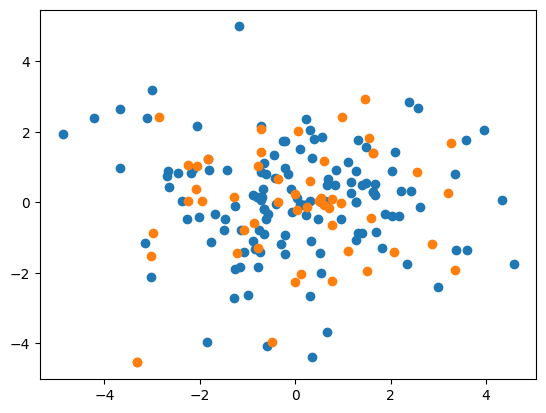

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
y = data.iloc[:, 12].to_numpy(dtype=int) 
X_scaled = StandardScaler().fit_transform(data.iloc[:, :12])
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca).join(data.iloc[:, 12])

plt.scatter(X_pca_df[X_pca_df[12] == 1].iloc[:, 0], X_pca_df[X_pca_df[12] == 1].iloc[:, 1], label='Relaxed')
plt.scatter(X_pca_df[X_pca_df[12] == 2].iloc[:, 0], X_pca_df[X_pca_df[12] == 2].iloc[:, 1], label="Motor")

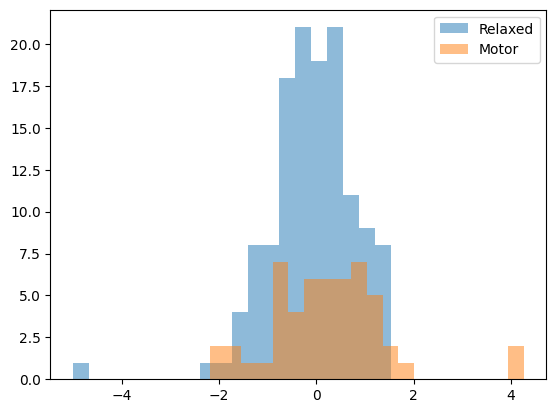

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.hist(X_lda[y==1], alpha=0.5, label='Relaxed', bins=20)
plt.hist(X_lda[y==2], alpha=0.5, label='Motor', bins=20)
plt.legend()

<Axes: >

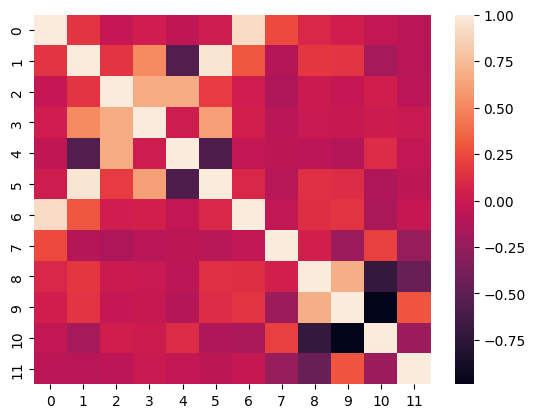

In [12]:
data.iloc[:, :12].corr()
sns.heatmap(data.iloc[:, :12].corr())

In [24]:
import pandas as pd
from scipy import stats

# Split your training data by class
class1 = data[data["Label"] == 1.0]   # relaxed
class2 = data[data["Label"] == 2.0]   # planning

feature_names = [f'coef_{i+1}' for i in range(12)]

pvalues = []
tstats = []

for i in range(12):
    t_stat, p_val = stats.ttest_ind(class1.iloc[:, i], class2.iloc[:, i], equal_var=False)
    tstats.append(t_stat)
    pvalues.append(p_val)

results = pd.DataFrame({
    'feature': feature_names,
    't_stat': tstats,
    'p_value': pvalues
}).sort_values('p_value')

print(results)

    feature    t_stat   p_value
8    coef_9  0.763039  0.447193
3    coef_4 -0.674658  0.501649
4    coef_5  0.633795  0.527716
6    coef_7  0.613754  0.540684
5    coef_6 -0.511618  0.609992
9   coef_10  0.487128  0.627469
0    coef_1  0.475043  0.635567
10  coef_11 -0.353154  0.724794
1    coef_2 -0.241761  0.809427
2    coef_3  0.134626  0.893188
11  coef_12 -0.124142  0.901485
7    coef_8  0.036489  0.970973


In [26]:
from statsmodels.stats.power import TTestIndPower
import numpy as np

analysis = TTestIndPower()

# What power did you actually have, given your sample sizes and observed effect sizes?
n1, n2 = 130, 52
for i, row in results.iterrows():
    # crude effect size estimate from t-stat and sample sizes
    effect_size = row['t_stat'] * np.sqrt(1/n1 + 1/n2)
    power = analysis.solve_power(effect_size=abs(effect_size), nobs1=n1, ratio=n2/n1, alpha=0.05)
    print(f"{row['feature']}: effect_size={effect_size:.3f}, power={power:.3f}")

coef_9: effect_size=0.125, power=0.118
coef_4: effect_size=-0.111, power=0.103
coef_5: effect_size=0.104, power=0.097
coef_7: effect_size=0.101, power=0.094
coef_6: effect_size=-0.084, power=0.080
coef_10: effect_size=0.080, power=0.077
coef_1: effect_size=0.078, power=0.076
coef_11: effect_size=-0.058, power=0.064
coef_2: effect_size=-0.040, power=0.057
coef_3: effect_size=0.022, power=0.052
coef_12: effect_size=-0.020, power=0.052
coef_8: effect_size=0.006, power=0.050


In [25]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 673.6 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.6 MB 980.5 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.6 MB 980.5 kB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.6 MB 859.3 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.6 MB 897.8 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.6 MB 949.7 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.6 MB 995.2 kB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.6 MB 995.2 kB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.6 MB 989.7 kB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.6 MB 1.0 MB/s eta 0:00:08
   ---------- -


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
"""
Final model comparison for Planning Relax EEG classification.

Given the t-test results showed no individually significant feature,
this script focuses on MULTIVARIATE methods:
  - Engineered interaction features (ratios/products of correlated pairs)
  - Multiple model families compared fairly (with class imbalance handling)
  - A dummy baseline so you know what "beating chance" actually looks like
  - Nested-style evaluation: tune on CV, report on held-out test + full CV
"""

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.model_selection import LeaveOneOut

RANDOM_STATE = 42

# =====================================================================
# 1. Load data + engineer features
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None).iloc[:,:13]
X_raw = df.iloc[:, :12].values
y = df.iloc[:, 12].values

feat_df = pd.DataFrame(X_raw, columns=[f'c{i+1}' for i in range(12)])

# Correlated pairs identified from your heatmap: (2,3) (8,9) (10,11) (1,4) (9,10) (3,4)
# 0-indexed columns: c2-c3, c8-c9, c10-c11, c1-c4, c9-c10, c3-c4
pairs = [(2, 3), (8, 9), (10, 11), (1, 4), (9, 10), (3, 4)]

for a, b in pairs:
    ca, cb = f'c{a}', f'c{b}'
    feat_df[f'{ca}_div_{cb}'] = feat_df[ca] / (feat_df[cb].replace(0, 1e-6))
    feat_df[f'{ca}_x_{cb}'] = feat_df[ca] * feat_df[cb]
    feat_df[f'{ca}_minus_{cb}'] = feat_df[ca] - feat_df[cb]

X_engineered = feat_df.values
print(f"Original features: {X_raw.shape[1]}, Engineered total: {X_engineered.shape[1]}")

# =====================================================================
# 2. Train/test split + CV setup
# =====================================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train_eng, X_test_eng, _, _ = train_test_split(
    X_engineered, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# =====================================================================
# 3. Dummy baselines (know what "beating chance" looks like)
# =====================================================================
print("\n" + "="*60)
print("BASELINES")
print("="*60)

for strategy in ['most_frequent', 'stratified', 'uniform']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    scores = cross_val_score(dummy, X_train_raw, y_train, cv=cv, scoring='f1_macro')
    print(f"Dummy ({strategy}): f1_macro = {scores.mean():.3f} ± {scores.std():.3f}")

# =====================================================================
# 4. Define models + hyperparameter grids
# =====================================================================
models = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
        ]),
        'param_grid': {'clf__C': [0.01, 0.1, 1, 10, 100]}
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__C': [0.1, 1, 10, 100],
            'clf__gamma': ['scale', 0.001, 0.01, 0.1],
            'clf__kernel': ['linear', 'rbf', 'poly']
        }
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__n_estimators': [100, 300],
            'clf__max_depth': [3, 5, 8, None],
            'clf__min_samples_leaf': [1, 3, 5]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__n_estimators': [50, 100, 200],
            'clf__max_depth': [2, 3, 4],
            'clf__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'LDA': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis())
        ]),
        'param_grid': {'clf__solver': ['svd', 'lsqr']}
    },
    'KNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'param_grid': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights': ['uniform', 'distance']
        }
    },
}

# =====================================================================
# 5. Run each model on BOTH raw and engineered feature sets
# =====================================================================
feature_sets = {
    'raw_12': (X_train_raw, X_test_raw),
    'engineered': (X_train_eng, X_test_eng),
}

all_results = []
fitted_models = {}

for fs_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{'='*60}\nFEATURE SET: {fs_name}\n{'='*60}")

    for model_name, cfg in models.items():
        grid = GridSearchCV(cfg['pipeline'], cfg['param_grid'], cv=cv,
                             scoring='f1_macro', n_jobs=-1)
        grid.fit(X_tr, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_te)

        bal_acc = balanced_accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')

        key = f"{model_name} ({fs_name})"
        fitted_models[key] = best_model

        all_results.append({
            'Model': model_name,
            'Feature set': fs_name,
            'Best params': grid.best_params_,
            'CV f1_macro': grid.best_score_,
            'Test f1_macro': test_f1,
            'Test balanced_acc': bal_acc,
        })

        print(f"{model_name:20s} CV f1_macro={grid.best_score_:.3f}  "
              f"Test f1_macro={test_f1:.3f}  Test bal_acc={bal_acc:.3f}")

# =====================================================================
# 6. Summary table, sorted by CV score (most trustworthy given small test set)
# =====================================================================
results_df = pd.DataFrame(all_results).sort_values('CV f1_macro', ascending=False)
print("\n" + "="*60)
print("FULL SUMMARY (sorted by CV f1_macro)")
print("="*60)
print(results_df[['Model', 'Feature set', 'CV f1_macro', 'Test f1_macro', 'Test balanced_acc']]
      .round(3).to_string(index=False))

# =====================================================================
# 7. Deep dive into the winner
# =====================================================================
best = results_df.iloc[0]
best_key = f"{best['Model']} ({best['Feature set']})"
best_model = fitted_models[best_key]
X_te_best = feature_sets[best['Feature set']][1]

print(f"\nBest model: {best_key}")
print(f"Best params: {best['Best params']}")

y_pred_best = best_model.predict(X_te_best)
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

# Full-dataset CV for the winner (accuracy / balanced_accuracy / f1_macro side by side)
X_full = feature_sets[best['Feature set']][0]
X_full_all = np.vstack([feature_sets[best['Feature set']][0], feature_sets[best['Feature set']][1]])
y_full_all = np.concatenate([y_train, y_test])

print("\nFinal CV metrics (full dataset, winning model):")
for scoring in ['accuracy', 'balanced_accuracy', 'f1_macro']:
    scores = cross_val_score(best_model, X_full_all, y_full_all, cv=cv, scoring=scoring)
    print(f"  {scoring}: {scores.mean():.3f} ± {scores.std():.3f}")

Original features: 12, Engineered total: 30

BASELINES
Dummy (most_frequent): f1_macro = 0.418 ± 0.007
Dummy (stratified): f1_macro = 0.480 ± 0.106
Dummy (uniform): f1_macro = 0.462 ± 0.170

FEATURE SET: raw_12
LogisticRegression   CV f1_macro=0.429  Test f1_macro=0.495  Test bal_acc=0.523
SVM                  CV f1_macro=0.510  Test f1_macro=0.607  Test bal_acc=0.619
RandomForest         CV f1_macro=0.475  Test f1_macro=0.487  Test bal_acc=0.490
GradientBoosting     CV f1_macro=0.432  Test f1_macro=0.487  Test bal_acc=0.526
LDA                  CV f1_macro=0.410  Test f1_macro=0.503  Test bal_acc=0.545
KNN                  CV f1_macro=0.453  Test f1_macro=0.327  Test bal_acc=0.346

FEATURE SET: engineered
LogisticRegression   CV f1_macro=0.428  Test f1_macro=0.446  Test bal_acc=0.451
SVM                  CV f1_macro=0.482  Test f1_macro=0.589  Test bal_acc=0.586
RandomForest         CV f1_macro=0.479  Test f1_macro=0.560  Test bal_acc=0.572
GradientBoosting     CV f1_macro=0.463  Test

In [45]:
"""
Final model comparison for Planning Relax EEG classification.

Given the t-test results showed no individually significant feature,
this script focuses on MULTIVARIATE methods:
  - Engineered interaction features (ratios/products of correlated pairs)
  - Multiple model families compared fairly (with class imbalance handling)
  - A dummy baseline so you know what "beating chance" actually looks like
  - Nested-style evaluation: tune on CV, report on held-out test + full CV
"""

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneOut, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.base import clone

RANDOM_STATE = 42

# =====================================================================
# 1. Load data + engineer features
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X_raw = df.iloc[:, :12].values
y = df.iloc[:, 12].values

feat_df = pd.DataFrame(X_raw, columns=[f'c{i+1}' for i in range(12)])

# Correlated pairs identified from your heatmap: (2,3) (8,9) (10,11) (1,4) (9,10) (3,4)
# 0-indexed columns: c2-c3, c8-c9, c10-c11, c1-c4, c9-c10, c3-c4
pairs = [(2, 3), (8, 9), (10, 11), (1, 4), (9, 10), (3, 4)]

for a, b in pairs:
    ca, cb = f'c{a}', f'c{b}'
    feat_df[f'{ca}_div_{cb}'] = feat_df[ca] / (feat_df[cb].replace(0, 1e-6))
    feat_df[f'{ca}_x_{cb}'] = feat_df[ca] * feat_df[cb]
    feat_df[f'{ca}_minus_{cb}'] = feat_df[ca] - feat_df[cb]

X_engineered = feat_df.values
print(f"Original features: {X_raw.shape[1]}, Engineered total: {X_engineered.shape[1]}")

# =====================================================================
# 2. Train/test split + CV setup
# =====================================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train_eng, X_test_eng, _, _ = train_test_split(
    X_engineered, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# =====================================================================
# 3. Dummy baselines (know what "beating chance" looks like)
# =====================================================================
print("\n" + "="*60)
print("BASELINES")
print("="*60)

loo = LeaveOneOut()

for strategy in ['most_frequent', 'stratified', 'uniform']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    scores_5fold = cross_val_score(dummy, X_train_raw, y_train, cv=cv, scoring='f1_macro')
    scores_loo = cross_val_score(dummy, X_train_raw, y_train, cv=loo, scoring='accuracy')
    print(f"Dummy ({strategy}): 5-fold f1_macro = {scores_5fold.mean():.3f} ± {scores_5fold.std():.3f}  "
          f"| LOO accuracy = {scores_loo.mean():.3f}")

# =====================================================================
# 4. Define models + hyperparameter grids
# =====================================================================
models = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
        ]),
        'param_grid': {'clf__C': [0.01, 0.1, 1, 10, 100]}
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__C': [0.1, 1, 10, 100],
            'clf__gamma': ['scale', 0.001, 0.01, 0.1],
            'clf__kernel': ['linear', 'rbf', 'poly']
        }
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__n_estimators': [100, 300],
            'clf__max_depth': [3, 5, 8, None],
            'clf__min_samples_leaf': [1, 3, 5]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'clf__n_estimators': [50, 100, 200],
            'clf__max_depth': [2, 3, 4],
            'clf__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'LDA': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis())
        ]),
        'param_grid': {'clf__solver': ['svd', 'lsqr']}
    },
    'KNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'param_grid': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights': ['uniform', 'distance']
        }
    },
}

# =====================================================================
# 5. Run each model on BOTH raw and engineered feature sets
# =====================================================================
feature_sets = {
    'raw_12': (X_train_raw, X_test_raw),
    'engineered': (X_train_eng, X_test_eng),
}

all_results = []
fitted_models = {}

for fs_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n{'='*60}\nFEATURE SET: {fs_name}\n{'='*60}")

    for model_name, cfg in models.items():
        grid = GridSearchCV(cfg['pipeline'], cfg['param_grid'], cv=cv,
                             scoring='f1_macro', n_jobs=-1)
        grid.fit(X_tr, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_te)

        bal_acc = balanced_accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, average='macro')

        key = f"{model_name} ({fs_name})"
        fitted_models[key] = best_model

        all_results.append({
            'Model': model_name,
            'Feature set': fs_name,
            'Best params': grid.best_params_,
            'CV f1_macro': grid.best_score_,
            'Test f1_macro': test_f1,
            'Test balanced_acc': bal_acc,
        })

        print(f"{model_name:20s} CV f1_macro={grid.best_score_:.3f}  "
              f"Test f1_macro={test_f1:.3f}  Test bal_acc={bal_acc:.3f}")

# =====================================================================
# 6. Summary table, sorted by CV score (most trustworthy given small test set)
# =====================================================================
results_df = pd.DataFrame(all_results).sort_values('CV f1_macro', ascending=False)
print("\n" + "="*60)
print("FULL SUMMARY (sorted by CV f1_macro)")
print("="*60)
print(results_df[['Model', 'Feature set', 'CV f1_macro', 'Test f1_macro', 'Test balanced_acc']]
      .round(3).to_string(index=False))

# =====================================================================
# 7. Deep dive into the winner
# =====================================================================
best = results_df.iloc[0]
best_key = f"{best['Model']} ({best['Feature set']})"
best_model = fitted_models[best_key]
X_te_best = feature_sets[best['Feature set']][1]

print(f"\nBest model: {best_key}")
print(f"Best params: {best['Best params']}")

y_pred_best = best_model.predict(X_te_best)
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

# =====================================================================
# 8. Leave-One-Out CV for the winner — the most stable estimate given N=182
# =====================================================================
# 5-fold CV on 182 samples means each fold has only ~36 samples, which makes
# the CV estimate itself noisy (see the wide ± you got earlier). LOO trains
# on 181 samples and tests on the 1 left out, repeated 182 times — it uses
# almost all the data for training every time, giving a much more stable
# (if slightly more optimistic/pessimistic per-fold) estimate. It's slower
# but with this dataset size it's fast enough to just run.

X_full_all = np.vstack([feature_sets[best['Feature set']][0], feature_sets[best['Feature set']][1]])
y_full_all = np.concatenate([y_train, y_test])

print(f"\n{'='*60}")
print(f"LEAVE-ONE-OUT CV — winning model: {best_key}")
print(f"{'='*60}")

loo_preds = []
loo_true = []

for train_idx, test_idx in loo.split(X_full_all):
    X_tr, X_te_loo = X_full_all[train_idx], X_full_all[test_idx]
    y_tr, y_te_loo = y_full_all[train_idx], y_full_all[test_idx]

    # Refit the SAME architecture/hyperparameters found by GridSearchCV above.
    # (Re-tuning hyperparameters inside each LOO fold would be the fully
    # correct "nested CV" approach, but with 182 folds x full grid search
    # that's very slow — this gives a solid, honest estimate for the
    # already-chosen best configuration.)
    model_loo = clone(best_model)  # fresh, unfitted clone of same pipeline/params
    model_loo.fit(X_tr, y_tr)
    pred = model_loo.predict(X_te_loo)

    loo_preds.append(pred[0])
    loo_true.append(y_te_loo[0])

loo_preds = np.array(loo_preds)
loo_true = np.array(loo_true)

print("\nLOO classification report:")
print(classification_report(loo_true, loo_preds))
print("LOO confusion matrix:")
print(confusion_matrix(loo_true, loo_preds))
print(f"\nLOO accuracy:          {(loo_preds == loo_true).mean():.3f}")
print(f"LOO balanced_accuracy: {balanced_accuracy_score(loo_true, loo_preds):.3f}")
print(f"LOO f1_macro:          {f1_score(loo_true, loo_preds, average='macro'):.3f}")

# Also run LOO on the dummy baseline for direct, fair comparison
dummy_loo = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_loo_scores = cross_val_score(dummy_loo, X_full_all, y_full_all, cv=loo, scoring='accuracy')
print(f"\nFor comparison — Dummy (most_frequent) LOO accuracy: {dummy_loo_scores.mean():.3f}")

Original features: 12, Engineered total: 30

BASELINES
Dummy (most_frequent): 5-fold f1_macro = 0.418 ± 0.007  | LOO accuracy = 0.717
Dummy (stratified): 5-fold f1_macro = 0.480 ± 0.106  | LOO accuracy = 0.717
Dummy (uniform): 5-fold f1_macro = 0.462 ± 0.170  | LOO accuracy = 0.717

FEATURE SET: raw_12
LogisticRegression   CV f1_macro=0.429  Test f1_macro=0.495  Test bal_acc=0.523
SVM                  CV f1_macro=0.510  Test f1_macro=0.607  Test bal_acc=0.619
RandomForest         CV f1_macro=0.475  Test f1_macro=0.487  Test bal_acc=0.490
GradientBoosting     CV f1_macro=0.432  Test f1_macro=0.487  Test bal_acc=0.526
LDA                  CV f1_macro=0.410  Test f1_macro=0.503  Test bal_acc=0.545
KNN                  CV f1_macro=0.453  Test f1_macro=0.327  Test bal_acc=0.346

FEATURE SET: engineered
LogisticRegression   CV f1_macro=0.428  Test f1_macro=0.446  Test bal_acc=0.451
SVM                  CV f1_macro=0.482  Test f1_macro=0.589  Test bal_acc=0.586
RandomForest         CV f1_macr

In [34]:
data[data["Label"] == 1].iloc[:, 12].shape

(130,)

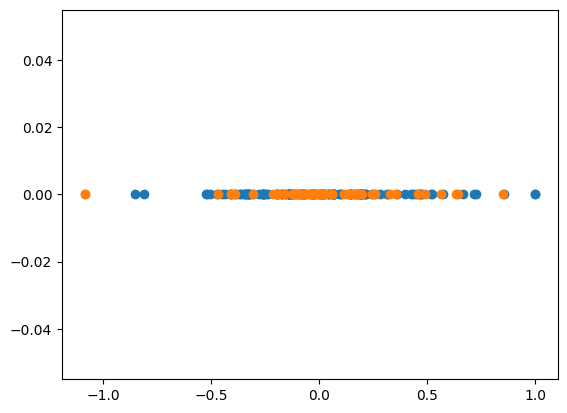

In [37]:
plt.scatter(data[data["Label"] == 1].iloc[:, 11], np.zeros(130))
plt.scatter(data[data["Label"] == 2].iloc[:, 11], np.zeros(52))

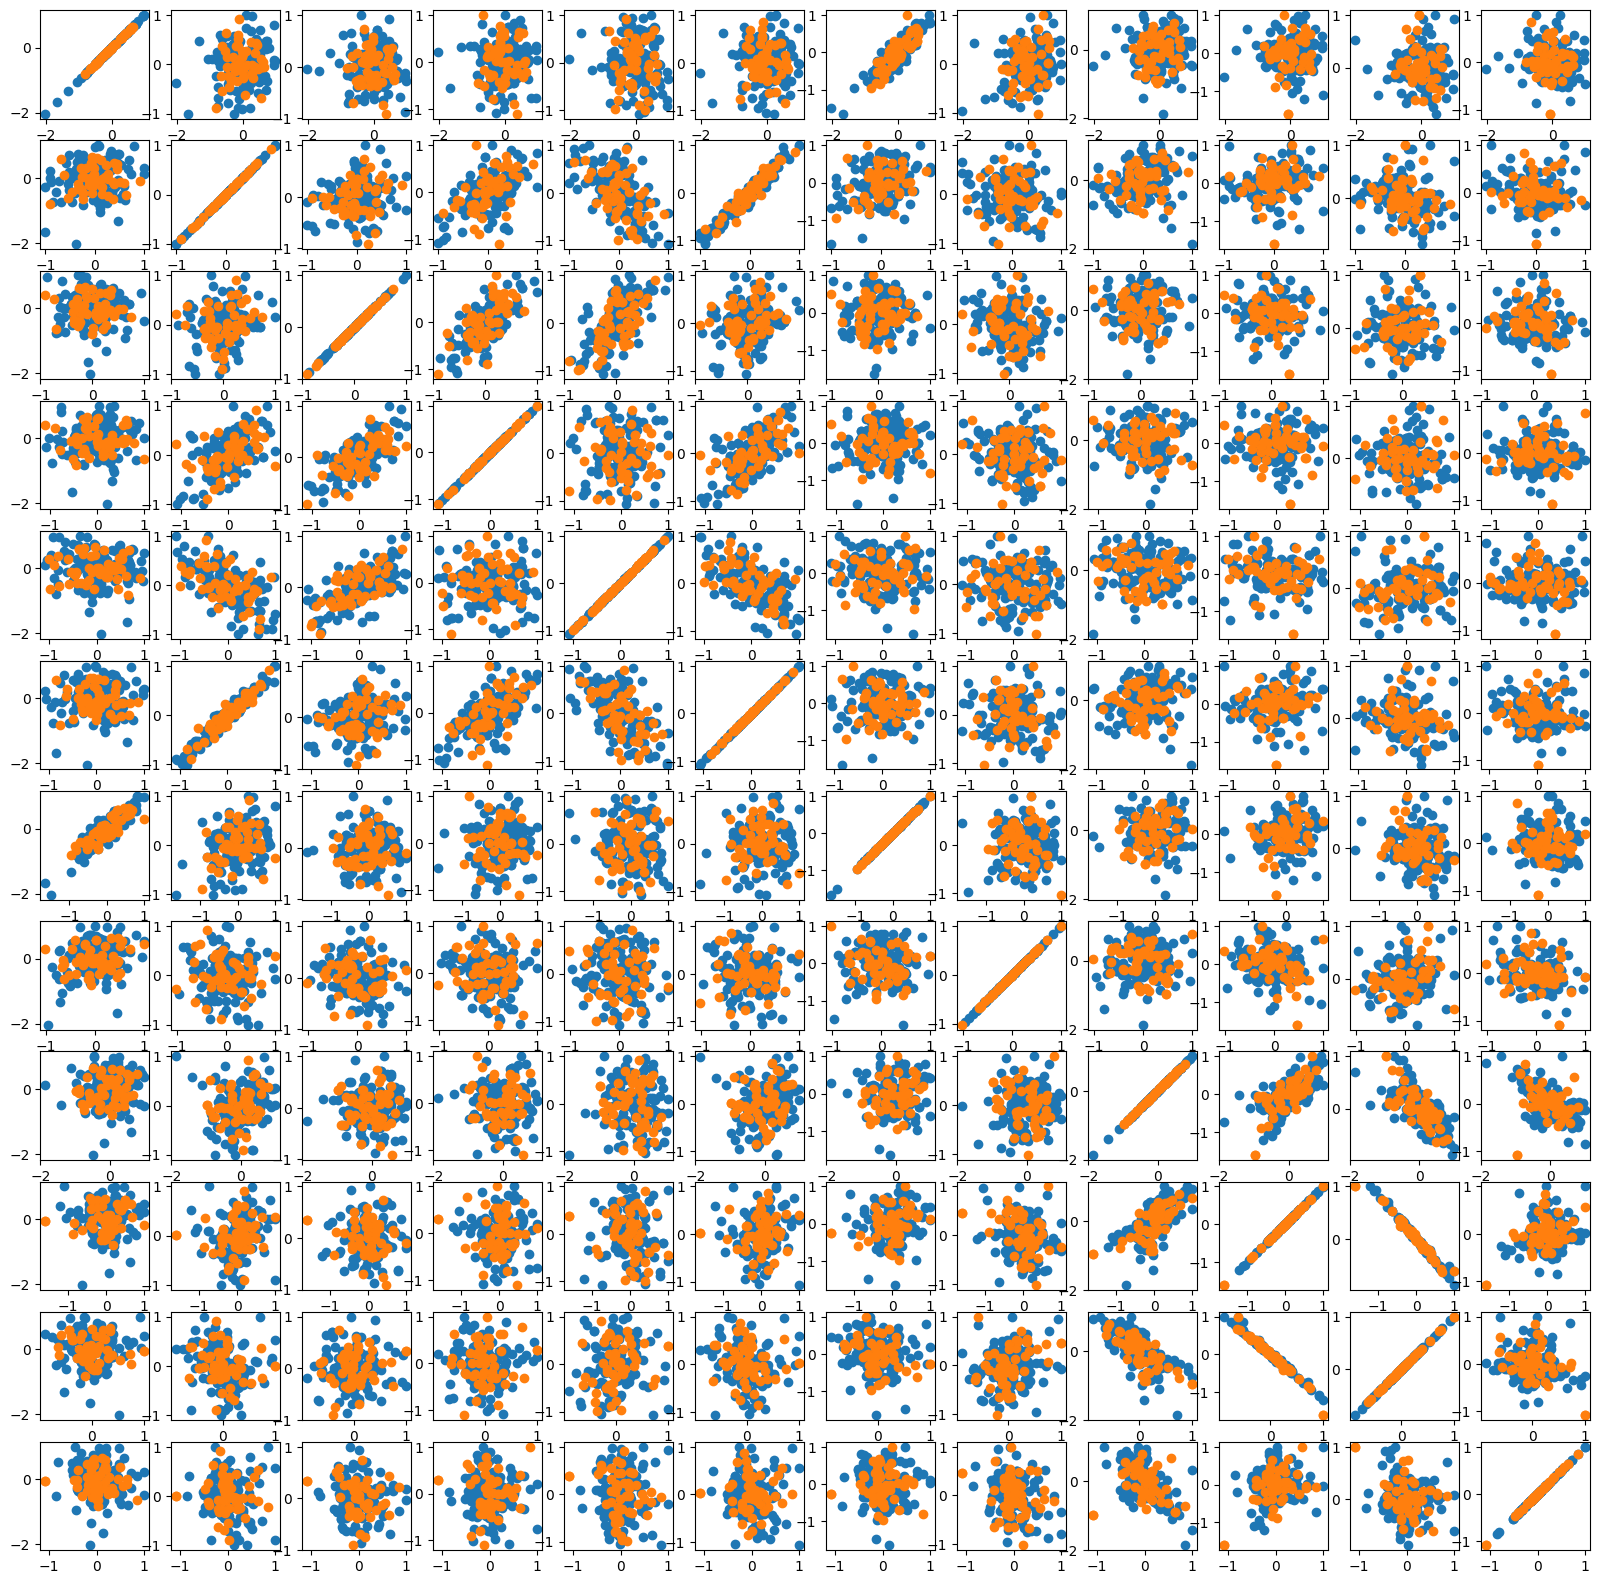

In [39]:
fig, ax = plt.subplots(nrows=12, ncols=12, figsize=(20,20))

for i in range(12):
    for j in range(12):
        ax[i, j].scatter(data[data["Label"] == 1].iloc[:, i], data[data["Label"] == 1].iloc[:, j])
        ax[i, j].scatter(data[data["Label"] == 2].iloc[:, i], data[data["Label"] == 2].iloc[:, j])

<Axes: >

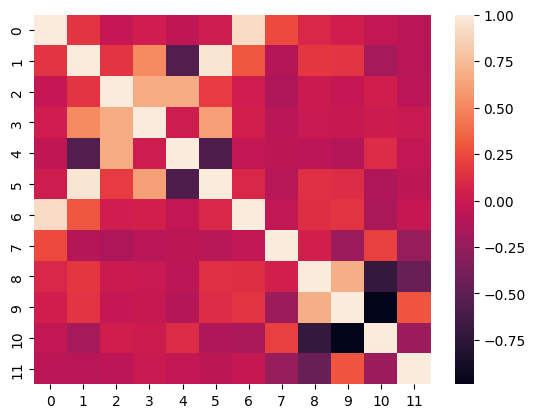

In [40]:
sns.heatmap(data.iloc[:, :12].corr())

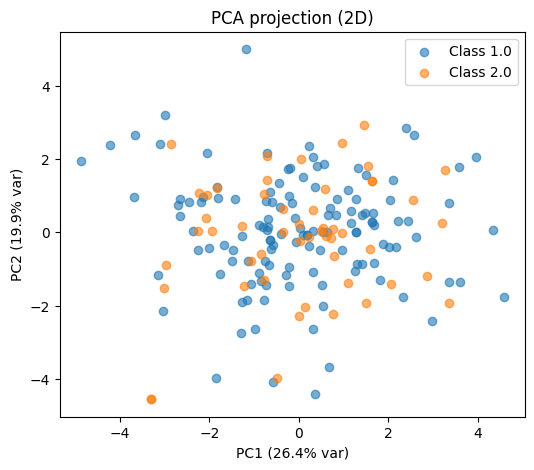

Variance explained by PC1+PC2: 46.3%


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = data.iloc[:, :12].values
y = data.iloc[:, 12].values

X_scaled = StandardScaler().fit_transform(X)

# ---- PCA (2D) ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for label, color in zip([1.0, 2.0], ['tab:blue', 'tab:orange']):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.6,
                label=f'Class {label}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA projection (2D)')
plt.legend()
plt.show()

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.1%}")

In [43]:
%pip install umap-learn

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 218.7 kB/s eta 0:00:11
   ------- -------------------------------- 0.5/2.8 MB 218.7 kB/s eta 0:00:11
   ------- -------------------------------- 0.5/2.8 MB 218.7 kB/s eta 0:00:11
   ------- -------------------------------- 0.5/2.8 MB 218.7 kB/s eta 0:00:11
   ------- -------------------------------- 0.5/2.8 MB 218.7 kB/s e


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


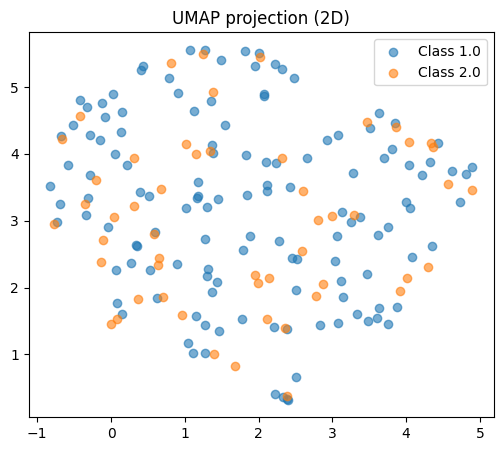

In [44]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for label, color in zip([1.0, 2.0], ['tab:blue', 'tab:orange']):
    mask = y == label
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, alpha=0.6,
                label=f'Class {label}')
plt.title('UMAP projection (2D)')
plt.legend()
plt.show()

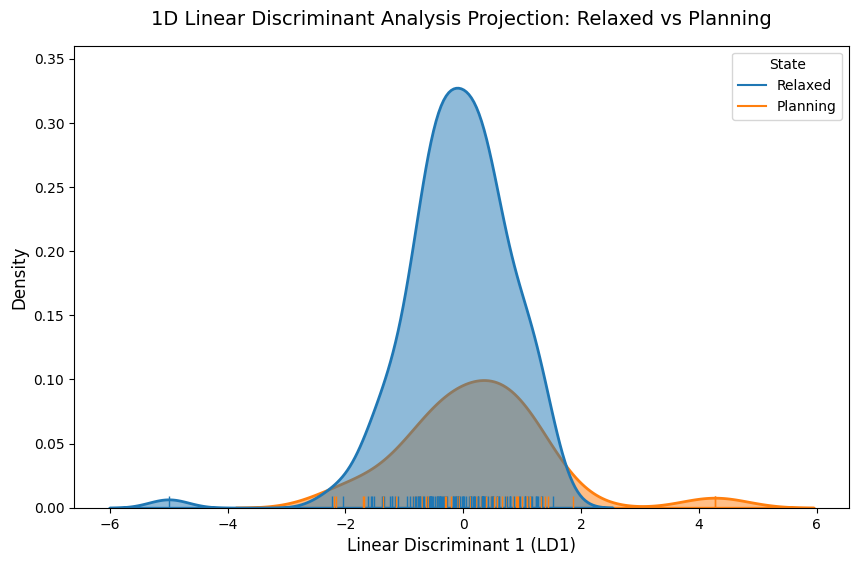

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================================
# 1. Load Data
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X = df.iloc[:, :12].values
y = df.iloc[:, 12].values

# =====================================================================
# 2. Fit and Transform with LDA
# =====================================================================
# LDA mathematically requires no scaling, though it doesn't hurt.
lda = LinearDiscriminantAnalysis()

# This transforms the 12D data down to a single 1D array
X_lda_1d = lda.fit_transform(X, y)

# =====================================================================
# 3. Prepare Data for Plotting
# =====================================================================
# Put the 1D LDA coordinates and the original labels into a new DataFrame
plot_df = pd.DataFrame({
    'LD1': X_lda_1d.flatten(),
    'State': y
})

# Map labels for a cleaner legend
plot_df['State'] = plot_df['State'].map({1.0: 'Relaxed', 2.0: 'Planning'})

# =====================================================================
# 4. Generate the Density Plot
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot KDE curves to show where the classes are concentrated
sns.kdeplot(
    data=plot_df, 
    x='LD1', 
    hue='State', 
    fill=True, 
    palette={'Relaxed': '#1f77b4', 'Planning': '#ff7f0e'},
    alpha=0.5,
    linewidth=2
)

plt.title("1D Linear Discriminant Analysis Projection: Relaxed vs Planning", fontsize=14, pad=15)
plt.xlabel("Linear Discriminant 1 (LD1)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Optional: Add a rugplot to see the exact locations of the individual samples (the minority class is small)
sns.rugplot(data=plot_df, x='LD1', hue='State', palette={'Relaxed': '#1f77b4', 'Planning': '#ff7f0e'})

plt.savefig('lda_1d_projection.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
"""
Final model comparison for Planning Relax EEG classification.

Focuses on MULTIVARIATE methods with:
 - Data standardized before feature engineering to stabilize ratios
 - Feature selection (SelectKBest) built into every pipeline
 - Complete elimination of train/test splits (using robust CV instead)
 - Clean Leave-One-Out CV for the final model
"""

import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import StratifiedKFold, LeaveOneOut, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif

# Ignore warnings for cleaner console output
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# =====================================================================
# 1. Load data, scale, and engineer features
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X_raw_unscaled = df.iloc[:, :12].values
y = df.iloc[:, 12].values

# Standardize BEFORE generating ratios to avoid extreme outliers
scaler = StandardScaler()
X_raw = scaler.fit_transform(X_raw_unscaled)

feat_df = pd.DataFrame(X_raw, columns=[f'c{i+1}' for i in range(12)])

# Correlated pairs identified from your heatmap
pairs = [(2, 3), (8, 9), (10, 11), (1, 4), (9, 10), (3, 4)]

for a, b in pairs:
    ca, cb = f'c{a}', f'c{b}'
    feat_df[f'{ca}_div_{cb}'] = feat_df[ca] / (feat_df[cb].replace(0, 1e-6))
    feat_df[f'{ca}_x_{cb}'] = feat_df[ca] * feat_df[cb]
    feat_df[f'{ca}_minus_{cb}'] = feat_df[ca] - feat_df[cb]

X_engineered = feat_df.values
print(f"Original features: {X_raw.shape[1]}, Engineered total: {X_engineered.shape[1]}")

# =====================================================================
# 2. CV setup (No fixed train/test split)
# =====================================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
loo = LeaveOneOut()

# =====================================================================
# 3. Dummy baselines
# =====================================================================
print("\n" + "="*60)
print("BASELINES")
print("="*60)

for strategy in ['most_frequent', 'stratified', 'uniform']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    scores_10fold = cross_val_score(dummy, X_raw, y, cv=cv, scoring='f1_macro')
    print(f"Dummy ({strategy}): 10-fold f1_macro = {scores_10fold.mean():.3f} ± {scores_10fold.std():.3f}")

# =====================================================================
# 4. Define models + hyperparameter grids with Feature Selection
# =====================================================================
# Note: StandardScaler is no longer in the pipeline because the data 
# was scaled in Step 1.
models = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__C': [0.01, 0.1, 1, 10]
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__C': [0.1, 1, 10, 100],
            'clf__kernel': ['linear', 'rbf', 'poly']
        }
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 5, None]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__n_estimators': [50, 100],
            'clf__max_depth': [2, 3]
        }
    },
    'LDA': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', LinearDiscriminantAnalysis())
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__solver': ['svd', 'lsqr']
        }
    },
    'KNN': {
        'pipeline': Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('clf', KNeighborsClassifier())
        ]),
        'param_grid': {
            'selector__k': [5, 10, 'all'],
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights': ['uniform', 'distance']
        }
    },
}

# =====================================================================
# 5. Run each model on BOTH raw and engineered feature sets
# =====================================================================
feature_sets = {
    'raw_12': X_raw,
    'engineered': X_engineered,
}

all_results = []
fitted_models = {}

for fs_name, X_data in feature_sets.items():
    print(f"\n{'='*60}\nFEATURE SET: {fs_name}\n{'='*60}")

    for model_name, cfg in models.items():
        grid = GridSearchCV(cfg['pipeline'], cfg['param_grid'], cv=cv, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_data, y)

        best_model = grid.best_estimator_
        key = f"{model_name} ({fs_name})"
        
        # Save both the model and the specific dataset it was trained on
        fitted_models[key] = {
            'model': best_model,
            'X': X_data
        }

        all_results.append({
            'Model': model_name,
            'Feature set': fs_name,
            'Best params': grid.best_params_,
            'CV f1_macro': grid.best_score_
        })

        print(f"{model_name:20s} CV f1_macro={grid.best_score_:.3f}")

# =====================================================================
# 6. Summary table
# =====================================================================
results_df = pd.DataFrame(all_results).sort_values('CV f1_macro', ascending=False)
print("\n" + "="*60)
print("FULL SUMMARY (sorted by 10-fold CV f1_macro)")
print("="*60)
print(results_df[['Model', 'Feature set', 'CV f1_macro']].round(3).to_string(index=False))

# =====================================================================
# 7. Leave-One-Out CV for the winner
# =====================================================================
best = results_df.iloc[0]
best_key = f"{best['Model']} ({best['Feature set']})"
best_model_info = fitted_models[best_key]

best_model = best_model_info['model']
X_best = best_model_info['X']

print(f"\n{'='*60}")
print(f"LEAVE-ONE-OUT CV — winning model: {best_key}")
print(f"{'='*60}")
print(f"Best params: {best['Best params']}\n")

# cross_val_predict runs the CV loop internally and returns the prediction 
# made for each sample when it was in the test set.
loo_preds = cross_val_predict(best_model, X_best, y, cv=loo, n_jobs=-1)

print("LOO classification report:")
print(classification_report(y, loo_preds))
print("LOO confusion matrix:")
print(confusion_matrix(y, loo_preds))
print(f"\nLOO accuracy:          {(loo_preds == y).mean():.3f}")
print(f"LOO balanced_accuracy: {balanced_accuracy_score(y, loo_preds):.3f}")
print(f"LOO f1_macro:          {f1_score(y, loo_preds, average='macro'):.3f}")

Original features: 12, Engineered total: 30

BASELINES
Dummy (most_frequent): 10-fold f1_macro = 0.417 ± 0.005
Dummy (stratified): 10-fold f1_macro = 0.565 ± 0.156
Dummy (uniform): 10-fold f1_macro = 0.486 ± 0.110

FEATURE SET: raw_12
LogisticRegression   CV f1_macro=0.389
SVM                  CV f1_macro=0.523
RandomForest         CV f1_macro=0.507
GradientBoosting     CV f1_macro=0.481
LDA                  CV f1_macro=0.417
KNN                  CV f1_macro=0.581

FEATURE SET: engineered
LogisticRegression   CV f1_macro=0.469
SVM                  CV f1_macro=0.483
RandomForest         CV f1_macro=0.616
GradientBoosting     CV f1_macro=0.565
LDA                  CV f1_macro=0.453
KNN                  CV f1_macro=0.558

FULL SUMMARY (sorted by 10-fold CV f1_macro)
             Model Feature set  CV f1_macro
      RandomForest  engineered        0.616
               KNN      raw_12        0.581
  GradientBoosting  engineered        0.565
               KNN  engineered        0.558
      